# Analyse de régression linéaire en R
  
Chaque partie commence par une explication, puis une cellule de code R que tu peux exécuter dans l’ordre.

**Objectif général :**  
Créer des données simulées, construire un modèle de régression linéaire, sélectionner les variables importantes avec les méthodes `forward`, `backward` et `stepwise`, puis vérifier les hypothèses du modèle et détecter les observations influentes.

## 1. Fixer le hasard et charger la bibliothèque `lmtest`

`set.seed(123)` fixe le générateur aléatoire.  
Cela permet d’obtenir les mêmes nombres aléatoires à chaque exécution, donc les mêmes résultats.

La bibliothèque `lmtest` contient des tests utiles pour les modèles de régression, par exemple :

- test de Durbin-Watson : indépendance des résidus ;
- test de Breusch-Pagan : homoscédasticité des résidus.

Dans un notebook, il vaut mieux installer le package seulement s’il n’existe pas déjà.

In [1]:
install.packages("lmtest", repos = "https://cloud.r-project.org")

Installing package into 'C:/Users/LENOVO/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'lmtest' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'lmtest'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\LENOVO\AppData\Local\R\win-library\4.5\00LOCK\lmtest\libs\x64\lmtest.dll to C:\Users\LENOVO\AppData\Local\R\win-library\4.5\lmtest\libs\x64\lmtest.dll: Permission denied"
Warning message:
"restored 'lmtest'"



The downloaded binary packages are in
	C:\Users\LENOVO\AppData\Local\Temp\Rtmp8m10rG\downloaded_packages


In [2]:
set.seed(123)  # Fixe le hasard pour avoir les mêmes résultats à chaque exécution

# Installer lmtest seulement si le package n'est pas déjà installé
if (!requireNamespace("lmtest", quietly = TRUE)) {
  install.packages("lmtest")
}

library(lmtest)

Warning message:
"package 'lmtest' was built under R version 4.5.3"
Loading required package: zoo

Warning message:
"package 'zoo' was built under R version 4.5.3"

Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric




## 2. Définir la taille de l’échantillon

On crée une variable `n` qui représente le nombre d’observations.  
Ici, `n <- 50` signifie que la base de données simulée contiendra 50 lignes.

In [2]:
n <- 50  # Nombre d'observations

## 3. Générer les variables explicatives

On génère une matrice de données avec 50 lignes et 5 colonnes.

`rnorm(n * 5, 0, 1)` génère `n * 5` valeurs aléatoires selon une loi normale centrée réduite :

- moyenne = 0 ;
- écart-type = 1.

Ensuite, `matrix(..., n, 5)` transforme ces valeurs en matrice avec `n` lignes et 5 colonnes.

In [3]:
data <- matrix(rnorm(n * 5, 0, 1), n, 5)

## 4. Nommer les colonnes

On donne un nom aux 5 variables explicatives : `x1`, `x2`, `x3`, `x4`, `x5`.

Ces variables seront utilisées plus tard pour expliquer la variable réponse `y`.

In [4]:
colnames(data) <- c("x1", "x2", "x3", "x4", "x5")

## 5. Afficher les données

`head(data)` affiche les 6 premières lignes de la matrice.  
`round(data, 2)` affiche toute la matrice avec seulement 2 chiffres après la virgule.

In [5]:
head(data)

x1,x2,x3,x4,x5
-0.56047565,0.25331851,-0.71040656,0.7877388,2.1988103
-0.23017749,-0.02854676,0.25688371,0.7690422,1.3124130
1.55870831,-0.04287046,-0.24669188,0.3322026,-0.2651451
0.07050839,1.36860228,-0.34754260,-1.0083766,0.5431941
0.12928774,-0.22577099,-0.95161857,-0.1194526,-0.4143399
1.71506499,1.51647060,-0.04502772,-0.2803953,-0.4762469


In [6]:
round(data, 2)

x1,x2,x3,x4,x5
-0.56,0.25,-0.71,0.79,2.20
-0.23,-0.03,0.26,0.77,1.31
1.56,-0.04,-0.25,0.33,-0.27
0.07,1.37,-0.35,-1.01,0.54
0.13,-0.23,-0.95,-0.12,-0.41
1.72,1.52,-0.05,-0.28,-0.48
0.46,-1.55,-0.78,0.56,-0.79
-1.27,0.58,-1.67,-0.37,-0.59
-0.69,0.12,-0.38,0.98,1.65
-0.45,0.22,0.92,-0.37,-0.05


## 6. Transformer la matrice en data frame

La fonction `lm()` en R fonctionne très bien avec un `data.frame`.  
On transforme donc la matrice `data` en tableau de données.

Un `data.frame` est une structure de données plus adaptée aux analyses statistiques.

In [7]:
data <- as.data.frame(data)

## 7. Construire la variable réponse `y`

Ici, on crée une variable réponse `y` selon un vrai modèle linéaire simulé :

\[
y = 2x_1 - 3x_2 + 1.5x_3 + 0.001x_4 - 0.02x_5 + \varepsilon
\]

où \(\varepsilon\) est une erreur aléatoire générée par `rnorm(n, 0, 0.5)`.

Cela veut dire :

- `x1`, `x2`, `x3` ont un effet important sur `y` ;
- `x4` et `x5` ont un effet presque nul ;
- une petite erreur aléatoire est ajoutée pour rendre les données réalistes.

In [8]:
y <- 2 * data$x1 - 3 * data$x2 + 1.5 * data$x3 +
     0.001 * data$x4 - 0.02 * data$x5 +
     rnorm(n, 0, 0.5)

y

[1] -3.17750658 -0.29580655  2.70966667 -4.45272790  0.31588231 -1.22186144
 [7]  4.94746891 -6.45897966 -2.40446934 -0.92639875  0.18433385  2.88768634
[13] -0.62799147  3.85741029  4.04877499  3.85554521 -0.24752974 -5.91759216
[19] -2.80779473 -8.56136317 -0.05231343  5.53931444 -5.48513695 -0.42397895
[25]  4.01109365 -7.65359519  2.98450404  4.13777108 -4.06614237  2.84953278
[31]  2.12855542 -0.69741053  3.15245366 -0.92952869 -0.70492523  2.17210291
[37] -4.25836368  0.49268154  3.11426756 -6.27404047 -2.71707020 -1.91751187
[43] -5.06239922  3.68274539 -3.06482601 -1.24449778 -8.62435590 -5.14877323
[49]  5.44037074  1.59604146

## 8. Construire le modèle complet

Le modèle complet utilise toutes les variables explicatives disponibles.

La formule `y ~ .` signifie :

- `y` est la variable à expliquer ;
- `.` signifie toutes les colonnes de `data`, donc `x1`, `x2`, `x3`, `x4`, `x5`.

`summary(modele_complet)` affiche les coefficients estimés, les p-values, le \(R^2\), etc.

In [9]:
modele_complet <- lm(y ~ ., data = data)

summary(modele_complet)


Call:
lm(formula = y ~ ., data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.04747 -0.27647 -0.07649  0.29247  1.01477 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.10543    0.07160   1.473    0.148    
x1           2.00508    0.07712  26.001   <2e-16 ***
x2          -3.04919    0.07916 -38.518   <2e-16 ***
x3           1.40258    0.07105  19.740   <2e-16 ***
x4           0.03294    0.07698   0.428    0.671    
x5          -0.06066    0.07668  -0.791    0.433    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.485 on 44 degrees of freedom
Multiple R-squared:  0.9859,	Adjusted R-squared:  0.9843 
F-statistic: 613.8 on 5 and 44 DF,  p-value: < 2.2e-16


## 9. Construire le modèle vide

Le modèle vide contient seulement la constante/intercept, sans aucune variable explicative.

La formule `y ~ 1` signifie que le modèle explique `y` uniquement par sa moyenne.

Ce modèle sert de point de départ pour la sélection ascendante.

In [10]:
modele_vide <- lm(y ~ 1, data = data)

summary(modele_vide)


Call:
lm(formula = y ~ 1, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.9980 -2.5230  0.1003  3.5045  6.1656 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  -0.6263     0.5467  -1.146    0.258

Residual standard error: 3.866 on 49 degrees of freedom


## 10. Sélection progressive ascendante — Forward selection

La méthode ascendante commence par le modèle vide.  
Ensuite, elle ajoute progressivement les variables qui améliorent le plus le modèle selon le critère AIC.

`scope` indique les limites de recherche :

- `lower = modele_vide` : modèle minimal ;
- `upper = modele_complet` : modèle maximal.

In [11]:
modele_forward <- step(
  modele_vide,
  scope = list(lower = modele_vide, upper = modele_complet),
  direction = "forward"
)

summary(modele_forward)

Start:  AIC=136.21
y ~ 1

       Df Sum of Sq    RSS     AIC
+ x2    1    453.27 279.06  89.971
+ x1    1    196.87 535.46 122.556
+ x3    1    172.18 560.15 124.809
<none>              732.33 136.210
+ x4    1      2.22 730.11 138.059
+ x5    1      1.07 731.26 138.137

Step:  AIC=89.97
y ~ x2

       Df Sum of Sq    RSS    AIC
+ x1    1   176.247 102.81 42.046
+ x3    1    98.416 180.65 70.226
+ x5    1    14.454 264.61 89.311
<none>              279.06 89.971
+ x4    1     3.462 275.60 91.346

Step:  AIC=42.05
y ~ x2 + x1

       Df Sum of Sq    RSS     AIC
+ x3    1    92.296  10.52 -69.939
<none>              102.81  42.046
+ x5    1     0.798 102.02  43.656
+ x4    1     0.020 102.80  44.036

Step:  AIC=-69.94
y ~ x2 + x1 + x3

       Df Sum of Sq    RSS     AIC
<none>              10.520 -69.939
+ x5    1  0.126383 10.393 -68.543
+ x4    1  0.022241 10.498 -68.044



Call:
lm(formula = y ~ x2 + x1 + x3, data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.00152 -0.31188 -0.04813  0.32568  1.06756 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.10696    0.07045   1.518    0.136    
x2          -3.04560    0.07643 -39.851   <2e-16 ***
x1           2.01437    0.07385  27.275   <2e-16 ***
x3           1.40484    0.06993  20.089   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4782 on 46 degrees of freedom
Multiple R-squared:  0.9856,	Adjusted R-squared:  0.9847 
F-statistic:  1052 on 3 and 46 DF,  p-value: < 2.2e-16


## 11. Calculer l’AIC du modèle forward

L’AIC est un critère qui aide à comparer les modèles.

Idée générale :

- un bon modèle doit bien expliquer les données ;
- mais il ne doit pas être trop complexe.

Plus l’AIC est petit, meilleur est le compromis entre qualité d’ajustement et simplicité.

`extractAIC()` et `AIC()` donnent des versions légèrement différentes car `AIC()` inclut une constante.

In [12]:
extractAIC(modele_forward)  # AIC = -2ln(L) + 2k
AIC(modele_forward)         # AIC = -2ln(L) + 2k + constante

[1]   4.00000 -69.93851

[1] 73.95535

## 12. Sélection descendante — Backward selection

La méthode descendante commence par le modèle complet.  
Elle retire progressivement les variables qui améliorent ou ne détériorent pas le critère AIC.

Cette méthode teste donc quelles variables peuvent être supprimées du modèle.

In [13]:
modele_backward <- step(
  modele_complet,
  scope = list(lower = modele_vide, upper = modele_complet),
  direction = "backward"
)

summary(modele_backward)
extractAIC(modele_backward)

Start:  AIC=-66.75
y ~ x1 + x2 + x3 + x4 + x5

       Df Sum of Sq    RSS     AIC
- x4    1      0.04  10.39 -68.543
- x5    1      0.15  10.50 -68.044
<none>               10.35 -66.750
- x3    1     91.67 102.02  45.656
- x1    1    159.03 169.38  71.005
- x2    1    349.00 359.35 108.614

Step:  AIC=-68.54
y ~ x1 + x2 + x3 + x5

       Df Sum of Sq    RSS     AIC
- x5    1      0.13  10.52 -69.939
<none>               10.39 -68.543
- x3    1     91.62 102.02  43.656
- x1    1    159.93 170.32  69.283
- x2    1    357.36 367.75 107.769

Step:  AIC=-69.94
y ~ x1 + x2 + x3

       Df Sum of Sq    RSS     AIC
<none>               10.52 -69.939
- x3    1     92.30 102.82  42.046
- x1    1    170.13 180.65  70.226
- x2    1    363.18 373.70 106.571



Call:
lm(formula = y ~ x1 + x2 + x3, data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.00152 -0.31188 -0.04813  0.32568  1.06756 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.10696    0.07045   1.518    0.136    
x1           2.01437    0.07385  27.275   <2e-16 ***
x2          -3.04560    0.07643 -39.851   <2e-16 ***
x3           1.40484    0.06993  20.089   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4782 on 46 degrees of freedom
Multiple R-squared:  0.9856,	Adjusted R-squared:  0.9847 
F-statistic:  1052 on 3 and 46 DF,  p-value: < 2.2e-16


[1]   4.00000 -69.93851

## 13. Sélection pas à pas — Stepwise selection

La méthode pas à pas combine les deux idées :

- elle peut ajouter une variable ;
- elle peut aussi retirer une variable déjà présente.

Ici, on commence avec le modèle vide et on autorise les deux directions avec `direction = "both"`.

In [14]:
modele_stepwise <- step(
  modele_vide,
  scope = list(lower = modele_vide, upper = modele_complet),
  direction = "both"
)

summary(modele_stepwise)

Start:  AIC=136.21
y ~ 1

       Df Sum of Sq    RSS     AIC
+ x2    1    453.27 279.06  89.971
+ x1    1    196.87 535.46 122.556
+ x3    1    172.18 560.15 124.809
<none>              732.33 136.210
+ x4    1      2.22 730.11 138.059
+ x5    1      1.07 731.26 138.137

Step:  AIC=89.97
y ~ x2

       Df Sum of Sq    RSS     AIC
+ x1    1    176.25 102.82  42.046
+ x3    1     98.42 180.65  70.226
+ x5    1     14.45 264.61  89.311
<none>              279.06  89.971
+ x4    1      3.46 275.60  91.346
- x2    1    453.27 732.33 136.210

Step:  AIC=42.05
y ~ x2 + x1

       Df Sum of Sq    RSS     AIC
+ x3    1     92.30  10.52 -69.939
<none>              102.82  42.046
+ x5    1      0.80 102.02  43.656
+ x4    1      0.02 102.80  44.036
- x1    1    176.25 279.06  89.971
- x2    1    432.65 535.46 122.556

Step:  AIC=-69.94
y ~ x2 + x1 + x3

       Df Sum of Sq    RSS     AIC
<none>               10.52 -69.939
+ x5    1      0.13  10.39 -68.543
+ x4    1      0.02  10.50 -68.044
- x3 


Call:
lm(formula = y ~ x2 + x1 + x3, data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.00152 -0.31188 -0.04813  0.32568  1.06756 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.10696    0.07045   1.518    0.136    
x2          -3.04560    0.07643 -39.851   <2e-16 ***
x1           2.01437    0.07385  27.275   <2e-16 ***
x3           1.40484    0.06993  20.089   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4782 on 46 degrees of freedom
Multiple R-squared:  0.9856,	Adjusted R-squared:  0.9847 
F-statistic:  1052 on 3 and 46 DF,  p-value: < 2.2e-16


## 14. Choisir le modèle final

On choisit ici le modèle obtenu par la méthode stepwise comme modèle final.

La variable `modele` contiendra donc le modèle que l’on va analyser dans la suite.

In [15]:
modele <- modele_stepwise

## 15. Résumé et graphiques de diagnostic du modèle final

`summary(modele)` donne les résultats statistiques du modèle final.

`plot(modele)` produit les graphiques de diagnostic classiques :

1. résidus vs valeurs ajustées ;
2. Q-Q plot des résidus ;
3. échelle-location ;
4. résidus vs leviers.

Ces graphiques servent à vérifier les hypothèses du modèle linéaire.

In [16]:
summary(modele)


Call:
lm(formula = y ~ x2 + x1 + x3, data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.00152 -0.31188 -0.04813  0.32568  1.06756 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.10696    0.07045   1.518    0.136    
x2          -3.04560    0.07643 -39.851   <2e-16 ***
x1           2.01437    0.07385  27.275   <2e-16 ***
x3           1.40484    0.06993  20.089   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4782 on 46 degrees of freedom
Multiple R-squared:  0.9856,	Adjusted R-squared:  0.9847 
F-statistic:  1052 on 3 and 46 DF,  p-value: < 2.2e-16


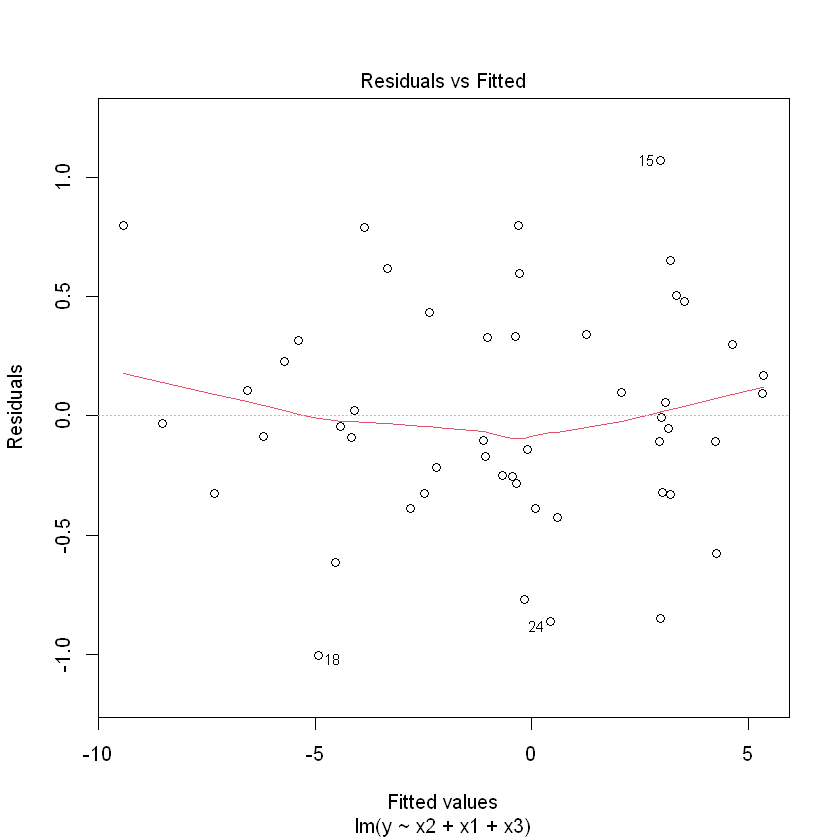

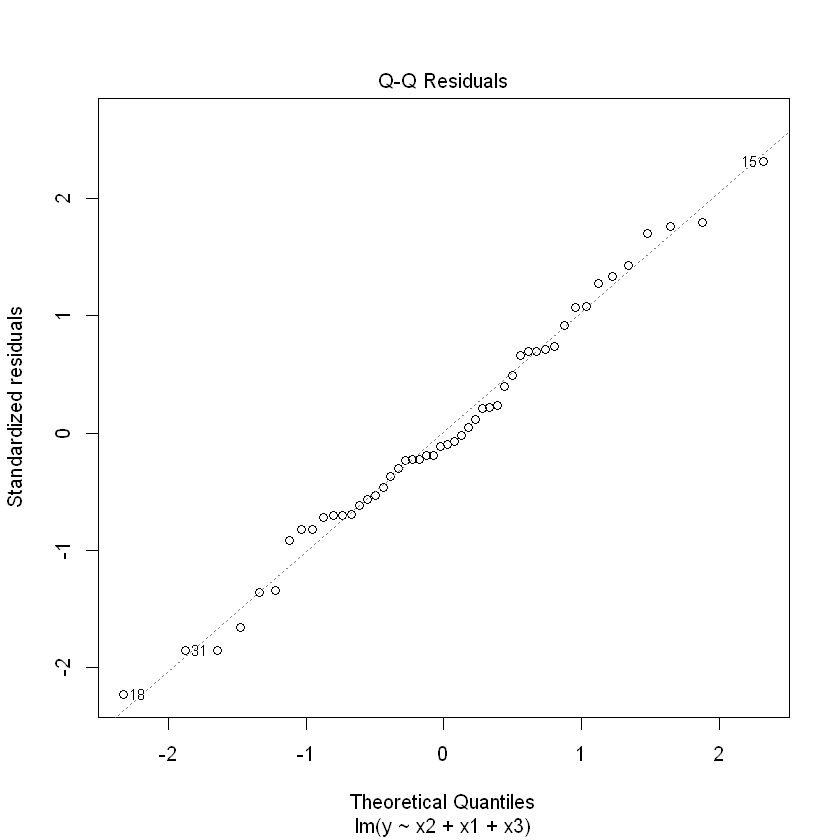

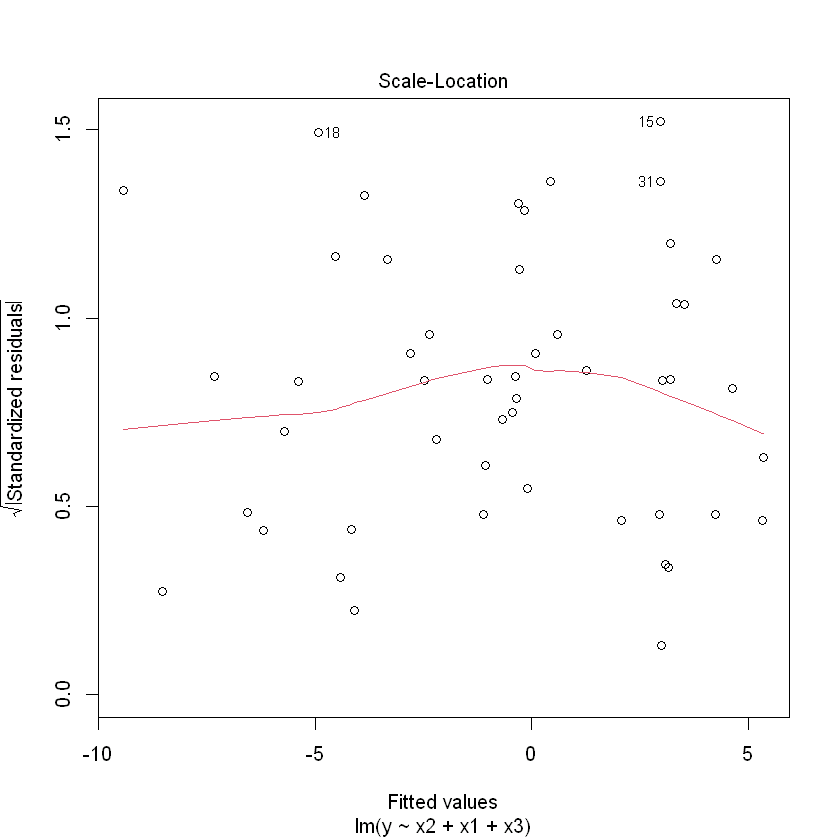

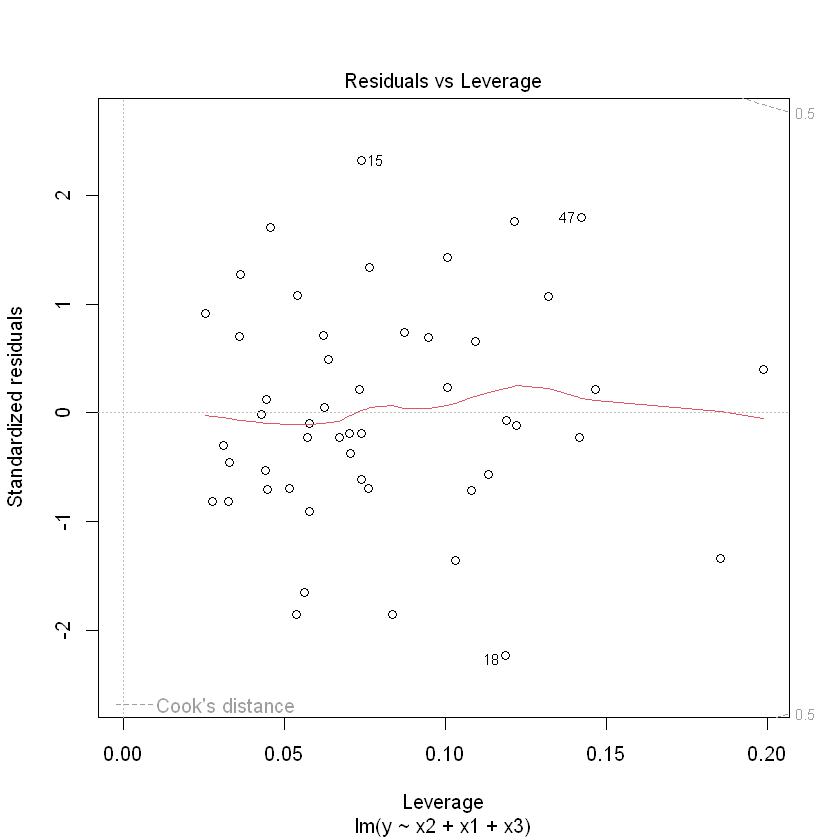

In [17]:
plot(modele)

## 16. Extraire les résidus

Les résidus sont les erreurs du modèle :

\[
e_i = y_i - \hat{y}_i
\]

Ils représentent la différence entre la valeur observée et la valeur prédite.

On les utilise pour vérifier les hypothèses du modèle.

In [18]:
res <- residuals(modele)

res

1            2            3            4            5            6 
-0.385938457 -0.386922230 -0.321113239 -0.045256619  0.597759394 -0.101780106 
           7            8            9           10           11           12 
 0.297842234  0.106066850 -0.216477782 -0.768999365 -0.423878224 -0.328039697 
          13           14           15           16           17           18 
-0.284195706  0.503381104  1.067558334  0.650431821 -0.140733520 -1.001524898 
          19           20           21           22           23           24 
-0.324984791 -0.033463004  0.330967436  0.169690898  0.226896755 -0.862847647 
          25           26           27           28           29           30 
 0.477464831 -0.323553160 -0.008053877 -0.105475741  0.022970468 -0.105905819 
          31           32           33           34           35           36 
-0.849270772  0.329135319  0.055572272 -0.249318910 -0.253876024  0.099091845 
          37           38           39           40           41           42 
-0.088614106  0.796317386 -0.051013311 -0.087334101  0.615291495  0.432899277 
          43           44           45           46           47           48 
 0.315323358 -0.577778578  0.788840791 -0.171403141  0.795526689 -0.614407628 
          49           50 
 0.094101010  0.339030884

## 17. Tester la normalité des résidus avec Shapiro-Wilk

Le test de Shapiro-Wilk vérifie si les résidus suivent une loi normale.

Hypothèses :

- \(H_0\) : les résidus suivent une loi normale ;
- \(H_1\) : les résidus ne suivent pas une loi normale.

Si la p-value est supérieure à 0.05, on ne rejette pas \(H_0\).

In [19]:
shapiro.test(res)


	Shapiro-Wilk normality test

data:  res
W = 0.98639, p-value = 0.8295


## 18. Tester la normalité avec Kolmogorov-Smirnov

Le test de Kolmogorov-Smirnov compare la distribution des résidus à une loi normale.

Ici, on utilise une loi normale avec :

- moyenne = `mean(res)` ;
- écart-type = `sd(res)`.

Remarque : pour les résidus d’un modèle linéaire, le test de Shapiro-Wilk est souvent plus adapté.

In [20]:
ks.test(res, "pnorm", mean(res), sd(res))


	Exact one-sample Kolmogorov-Smirnov test

data:  res
D = 0.069467, p-value = 0.9555
alternative hypothesis: two-sided


## 19. Tester l’indépendance des résidus avec Durbin-Watson

Le test de Durbin-Watson vérifie s’il existe une autocorrélation des résidus.

Hypothèses :

- \(H_0\) : les résidus sont indépendants ;
- \(H_1\) : les résidus sont autocorrélés.

Ce test est surtout utile lorsque les données sont ordonnées dans le temps.

In [21]:
dwtest(modele)


	Durbin-Watson test

data:  modele
DW = 1.9065, p-value = 0.3757
alternative hypothesis: true autocorrelation is greater than 0


## 20. Visualiser les résidus dans l’ordre des observations

Ce graphique affiche les résidus selon l’ordre des observations.

Il permet de voir visuellement s’il existe une structure, une tendance ou une dépendance entre les erreurs.

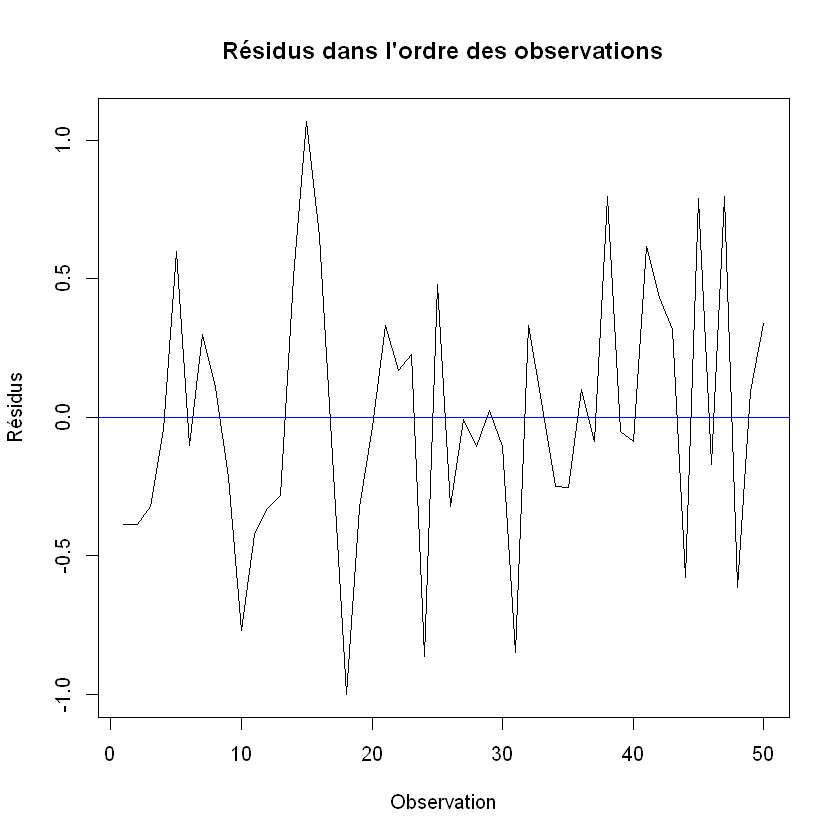

In [22]:
plot(
  residuals(modele),
  type = "l",
  xlab = "Observation",
  ylab = "Résidus",
  main = "Résidus dans l'ordre des observations"
)
abline(h = 0, col = "blue")

## 21. Tester l’homoscédasticité avec Breusch-Pagan

L’homoscédasticité signifie que la variance des erreurs est constante.

Le test de Breusch-Pagan vérifie cette hypothèse.

Hypothèses :

- \(H_0\) : homoscédasticité, variance constante ;
- \(H_1\) : hétéroscédasticité, variance non constante.

Si la p-value est supérieure à 0.05, on ne rejette pas l’hypothèse d’homoscédasticité.

In [23]:
bptest(modele)


	studentized Breusch-Pagan test

data:  modele
BP = 2.2518, df = 3, p-value = 0.5218


## 22. Calculer les leviers

Les leviers mesurent à quel point une observation est éloignée des autres selon les variables explicatives.

Une observation avec un levier élevé peut avoir une forte influence sur l’estimation du modèle.

In [24]:
leviers <- hatvalues(modele)

leviers

1          2          3          4          5          6          7 
0.03244289 0.02759999 0.07586080 0.05761211 0.03606157 0.14154881 0.10940023 
         8          9         10         11         12         13         14 
0.10057278 0.03271000 0.05618193 0.05765828 0.04447013 0.07386642 0.05381134 
        15         16         17         18         19         20         21 
0.07378271 0.10048971 0.03104087 0.11864643 0.05145929 0.11881056 0.06212955 
        22         23         24         25         26         27         28 
0.19894553 0.06370525 0.05362807 0.13190696 0.10813487 0.04276603 0.06683998 
        29         30         31         32         33         34         35 
0.06240405 0.05709535 0.08332117 0.03603564 0.04428371 0.04412234 0.11330865 
        36         37         38         39         40         41         42 
0.07319629 0.07377545 0.04561318 0.12213771 0.07021391 0.07619062 0.02535024 
        43         44         45         46         47         48         49 
0.09475906 0.18536294 0.12140322 0.07034542 0.14229479 0.10292206 0.14662090 
        50 
0.08716020

## 23. Calculer les résidus standardisés

Les résidus standardisés permettent de comparer les erreurs entre observations sur une même échelle.

Ils sont utiles pour détecter des observations atypiques.

In [25]:
residus_standardises <- rstandard(modele)

residus_standardises

1           2           3           4           5           6 
-0.82045791 -0.82049843 -0.69849945 -0.09748635  1.27314631 -0.22971092 
          7           8           9          10          11          12 
 0.65996597  0.23386930 -0.46026880 -1.65523016 -0.91308971 -0.70174741 
         13          14          15          16          17          18 
-0.61752885  1.08214285  2.31959266  1.43408623 -0.29896571 -2.23081326 
         19          20          21          22          23          24 
-0.69776889 -0.07454299  0.71464505  0.39646429  0.49034138 -1.85472594 
         25          26          27          28          29          30 
 1.07160518 -0.71642809 -0.01721363 -0.22832374  0.04960649 -0.22806702 
         31          32          33          34          35          36 
-1.85487278  0.70100409  0.11886944 -0.53324970 -0.56378304  0.21523881 
         37          38          39          40          41          42 
-0.19254013  1.70451385 -0.11385363 -0.18939516  1.33864765  0.91693621 
         43          44          45          46          47          48 
 0.69302771 -1.33861568  1.75983159 -0.37173592  1.79623139 -1.35649458 
         49          50 
 0.21300992  0.74202499

## 24. Calculer les résidus studentisés

Les résidus studentisés ressemblent aux résidus standardisés, mais ils sont calculés en tenant compte de l’influence de chaque observation.

Ils sont souvent utilisés pour détecter les valeurs aberrantes.

In [26]:
residus_studentises <- rstudent(modele)

residus_studentises

1           2           3           4           5           6 
-0.81749442 -0.81753540 -0.69455860 -0.09643086  1.28202158 -0.22733077 
          7           8           9          10          11          12 
 0.65586546  0.23145091 -0.45629029 -1.68818610 -0.91140752 -0.69782311 
         13          14          15          16          17          18 
-0.61332724  1.08420520  2.44146639  1.45122486 -0.29598592 -2.33643265 
         19          20          21          22          23          24 
-0.69382439 -0.07373275  0.71079130  0.39280291  0.48625475 -1.90715169 
         25          26          27          28          29          30 
 1.07337577 -0.71258471 -0.01702555 -0.22595640  0.04906564 -0.22570205 
         31          32          33          34          35          36 
-1.90731488  0.69707596  0.11758834 -0.52905942 -0.55955786  0.21299369 
         37          38          39          40          41          42 
-0.19051259  1.74178762 -0.11262516 -0.18739829  1.35058522  0.91531826 
         43          44          45          46          47          48 
 0.68906010 -1.35055165  1.80232693 -0.36822661  1.84238707 -1.36933645 
         49          50 
 0.21078586  0.73834734

## 25. Regrouper leviers et résidus dans un tableau

On rassemble les trois mesures dans un seul tableau pour faciliter l’interprétation :

- levier ;
- résidu standardisé ;
- résidu studentisé.

In [27]:
data.frame(
  leviers,
  residus_standardises,
  residus_studentises
)

,leviers,residus_standardises,residus_studentises
,<dbl>,<dbl>,<dbl>
1,0.03244289,-0.82045791,-0.81749442
2,0.02759999,-0.82049843,-0.81753540
3,0.07586080,-0.69849945,-0.69455860
4,0.05761211,-0.09748635,-0.09643086
5,0.03606157,1.27314631,1.28202158
6,0.14154881,-0.22971092,-0.22733077
7,0.10940023,0.65996597,0.65586546
8,0.10057278,0.23386930,0.23145091
9,0.03271000,-0.46026880,-0.45629029


## 26. Détecter les observations influentes avec les leviers

Ici, on marque comme influentes les observations dont le levier est supérieur à `0.5`.

Remarque : le seuil `0.5` est très strict et arbitraire.  
Dans la pratique, on utilise souvent des seuils comme \(2p/n\) ou \(3p/n\), où `p` est le nombre de paramètres du modèle.

In [28]:
leviers <- hatvalues(modele)

influ_levier <- ifelse(leviers > 0.5, "influent", "non influent")

data.frame(leviers, influ_levier)

,leviers,influ_levier
,<dbl>,<chr>
1,0.03244289,non influent
2,0.02759999,non influent
3,0.07586080,non influent
4,0.05761211,non influent
5,0.03606157,non influent
6,0.14154881,non influent
7,0.10940023,non influent
8,0.10057278,non influent
9,0.03271000,non influent


## 27. Détecter les observations influentes avec les résidus studentisés

On calcule un seuil basé sur la loi de Student.

Une observation est considérée comme potentiellement influente si la valeur absolue de son résidu studentisé dépasse ce seuil.

Ici, le degré de liberté est calculé automatiquement avec `df.residual(modele)`.

In [29]:
residus_studentises <- rstudent(modele)

seuil <- qt(0.975, df = df.residual(modele))

influ_residus <- ifelse(
  abs(residus_studentises) > seuil,
  "influent",
  "non influent"
)

table1 <- data.frame(residus_studentises, influ_residus)

table2 <- table1[table1$influ_residus == "influent", ]

table2

,residus_studentises,influ_residus
,<dbl>,<chr>
15,2.441466,influent
18,-2.336433,influent


## 28. Graphique des résidus studentisés

Ce graphique affiche les résidus studentisés pour toutes les observations.

Les lignes rouges indiquent les seuils positif et négatif.  
Les observations qui dépassent ces seuils peuvent être considérées comme atypiques.

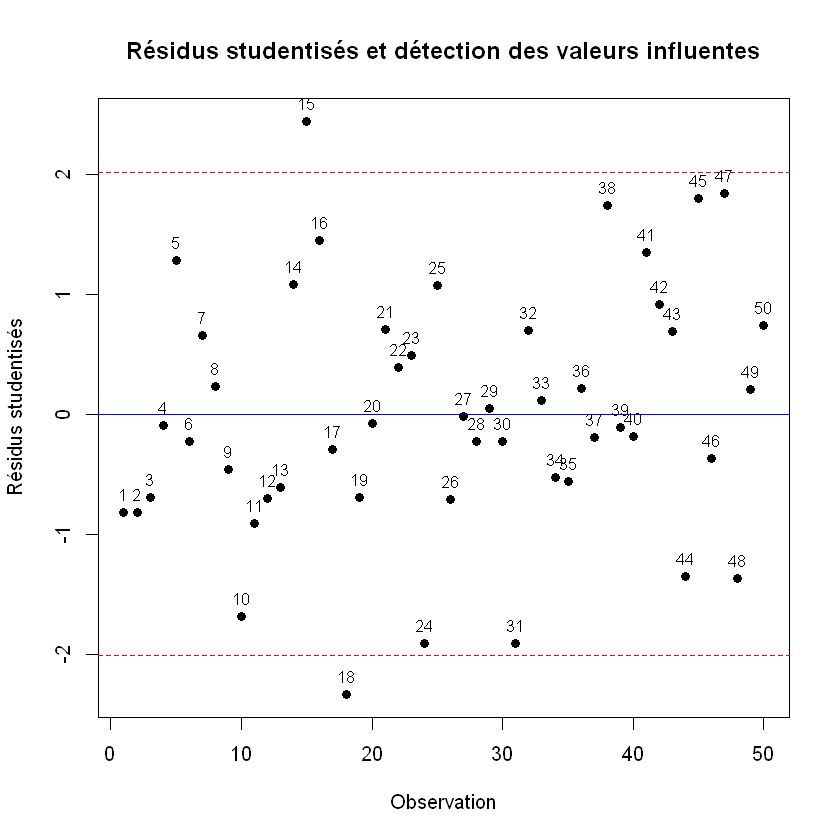

In [30]:
plot(
  residus_studentises,
  pch = 19,
  xlab = "Observation",
  ylab = "Résidus studentisés",
  main = "Résidus studentisés et détection des valeurs influentes"
)

text(1:n, residus_studentises, labels = 1:n, pos = 3, cex = 0.8)

abline(h = seuil, col = "red", lty = 2)
abline(h = -seuil, col = "red", lty = 2)
abline(h = 0, col = "blue")

## 29. Calculer la distance de Cook

La distance de Cook mesure l’influence globale d’une observation sur le modèle.

Une observation avec une grande distance de Cook peut modifier fortement les coefficients du modèle si elle est retirée.

On utilise souvent le seuil \(4/n\) comme règle pratique.

In [31]:
cook <- cooks.distance(modele)

cook

1            2            3            4            5            6 
5.642812e-03 4.777046e-03 1.001272e-02 1.452485e-04 1.515975e-02 2.175174e-03 
           7            8            9           10           11           12 
1.337577e-02 1.528977e-03 1.790964e-03 4.077230e-02 1.275323e-02 5.729620e-03 
          13           14           15           16           17           18 
7.603752e-03 1.664966e-02 1.071532e-01 5.743889e-02 7.158321e-04 1.674831e-01 
          19           20           21           22           23           24 
6.603451e-03 1.873007e-04 8.458165e-03 9.759337e-03 4.089778e-03 4.873375e-02 
          25           26           27           28           29           30 
4.362255e-02 1.555793e-02 3.309527e-06 9.335172e-04 4.094625e-05 7.874046e-04 
          31           32           33           34           35           36 
7.818193e-02 4.592533e-03 1.636800e-04 3.281387e-03 1.015441e-02 9.147080e-04 
          37           38           39           40           41           42 
7.382070e-04 3.471419e-02 4.508760e-04 6.772015e-04 3.694807e-02 5.467035e-03 
          43           44           45           46           47           48 
1.256891e-02 1.019320e-01 1.069850e-01 2.614107e-03 1.338183e-01 5.277818e-02 
          49           50 
1.948918e-03 1.314319e-02

## 30. Graphique de la distance de Cook

Ce graphique permet de voir quelles observations dépassent le seuil \(4/n\).

Les observations dépassant ce seuil sont affichées avec leur numéro.

15        18        44        45        47 
0.1071532 0.1674831 0.1019320 0.1069850 0.1338183

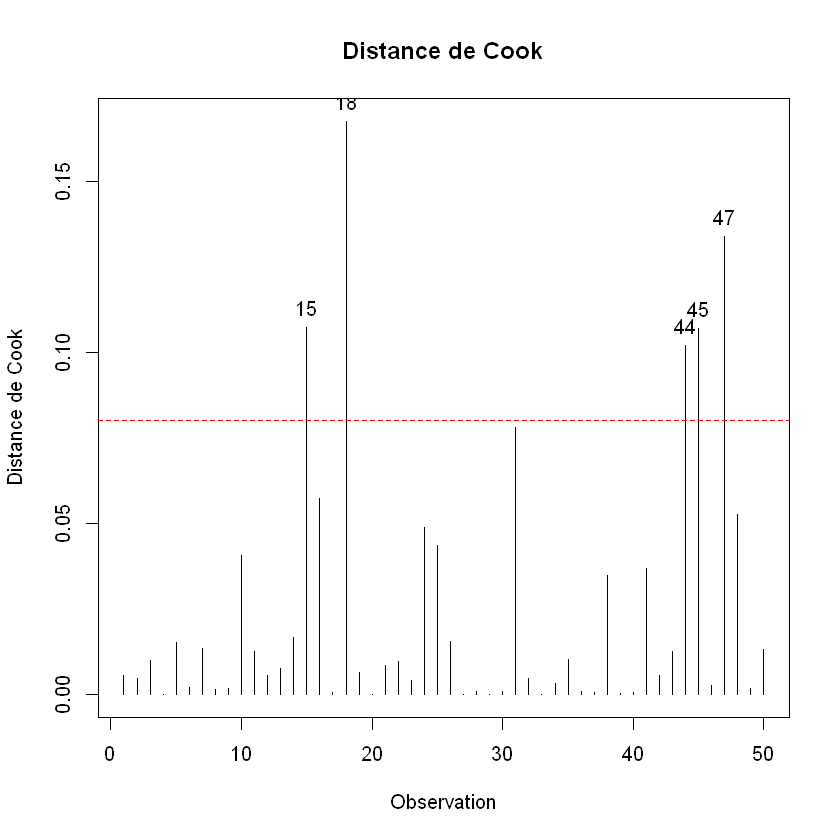

In [32]:
plot(
  cook,
  type = "h",
  xlab = "Observation",
  ylab = "Distance de Cook",
  main = "Distance de Cook"
)

abline(h = 4 / n, col = "red", lty = 2)

infl <- which(cook > 4 / n)

text(infl, cook[infl], labels = infl, pos = 3)

cook[cook > 4 / n]

## 31. Conclusion

Ce notebook a permis de faire les étapes suivantes :

1. simuler des données ;
2. créer une variable réponse `y` ;
3. ajuster un modèle de régression linéaire ;
4. sélectionner les variables avec `forward`, `backward` et `stepwise` ;
5. vérifier les hypothèses du modèle ;
6. détecter les observations potentiellement influentes avec les leviers, les résidus studentisés et la distance de Cook.

Pour exécuter ce notebook correctement, il faut utiliser un kernel R dans Jupyter, par exemple **IRkernel**.